# **Protocole ML commun — Projet Plantes**

**But :** comparer nos 4 modèles sur les mêmes données, pour que l'écart de score reflète l'algorithme, pas le pipeline.

**Figé :** features (pixels bruts et HOG), split train/val/test, métriques. **À modifier :** uniquement la section 4 (ton modèle).

---

### ⚠️ Avant de commencer — raccourci Drive (une fois)

`Projet_Plantes` est en "Partagés avec moi" — Colab ne le voit pas tel quel :

Drive → Partagés avec moi → clic droit sur `Projet_Plantes` → Organiser → Ajouter un raccourci → Mon Drive.

La cellule 1 vérifie que c'est fait.

---

### Pourquoi ce protocole

- **Anti-fuite** : les augmentations d'une même feuille restaient parfois des deux côtés du split, gonflant les scores. Split **groupé** (même que le CNN, 2.2.4/3.2.4) : toutes les versions d'une feuille restent ensemble.
- **Features communes** : pixels bruts (32×32) et HOG, mêmes pour tout le monde — sinon impossible de savoir si l'écart vient du modèle ou du pipeline.

Pas besoin des images : tout est déjà dans les `.npz`.

In [ ]:
# ============================================================
# 1. VÉRIFICATION DE L'ACCÈS — à lancer en premier
# ============================================================
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

BASE = Path("/content/drive/MyDrive/Projet_Plantes")

if not BASE.exists():
    print("❌ Projet_Plantes INTROUVABLE dans MyDrive.\n")
    print("Le dossier est en 'Partagés avec moi' : Colab ne le voit pas.")
    print("Corrige en 10 secondes :")
    print("   1. Google Drive → Partagés avec moi")
    print("   2. Clic droit sur 'Projet_Plantes'")
    print("   3. Organiser → Ajouter un raccourci")
    print("   4. Choisis 'Mon Drive' → Ajouter")
    print("   5. Relance cette cellule\n")
    raise SystemExit("Raccourci Drive manquant — voir instructions ci-dessus.")

print("✅ Projet_Plantes accessible")
print("Contenu :", sorted(p.name for p in BASE.iterdir())[:10])

Mounted at /content/drive
✅ Projet_Plantes accessible
Contenu : ['Bronislaw', 'Copie de PROTOCOLE_ML_COMMUN (1).ipynb', 'Ghislain', 'MALADIES.zip', 'MUTUALISATION ML', 'Messaline', 'Modèles CNN', 'PROTOCOLE_ML_COMMUN (1).ipynb', 'Paul el Forzli', 'README.txt']


[0]	validation_0-mlogloss:2.45182	validation_0-merror:0.51357	validation_1-mlogloss:2.47263	validation_1-merror:0.56589
[25]	validation_0-mlogloss:1.12510	validation_0-merror:0.23510	validation_1-mlogloss:1.32069	validation_1-merror:0.33000
[50]	validation_0-mlogloss:0.73885	validation_0-merror:0.15636	validation_1-mlogloss:1.00213	validation_1-merror:0.27403
[75]	validation_0-mlogloss:0.54127	validation_0-merror:0.11010	validation_1-mlogloss:0.84090	validation_1-merror:0.23991
[100]	validation_0-mlogloss:0.42084	validation_0-merror:0.08047	validation_1-mlogloss:0.74274	validation_1-merror:0.21730
[125]	validation_0-mlogloss:0.33343	validation_0-merror:0.05837	validation_1-mlogloss:0.67083	validation_1-merror:0.19767
[150]	validation_0-mlogloss:0.26910	validation_0-merror:0.04288	validation_1-mlogloss:0.61582	validation_1-merror:0.18366
[175]	validation_0-mlogloss:0.21958	validation_0-merror:0.03130	validation_1-mlogloss:0.57263	validation_1-merror:0.17284
[200]	validation_0-mlogloss:0

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [12:28:19] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Accuracy : 0.8566375364128173
F1 macro : 0.8508959268005482

                       precision    recall  f1-score   support

                apple       0.77      0.76      0.77      1422
            blueberry       0.85      0.87      0.86       341
cherry_including_sour       0.84      0.84      0.84       659
                grape       0.94      0.93      0.94      1347
                maize       0.93      0.97      0.95      1318
               orange       0.93      0.94      0.93       842
                peach       0.89      0.75      0.81       671
          pepper_bell       0.74      0.64      0.69       738
               potato       0.76      0.81      0.79      1060
            raspberry       0.82      0.80      0.81       358
              soybean       0.89      0.94      0.91       750
               squash       0.91      0.82      0.86       334
           strawberry       0.89      0.90      0.89       691
               tomato       0.85      0.87      0.86    

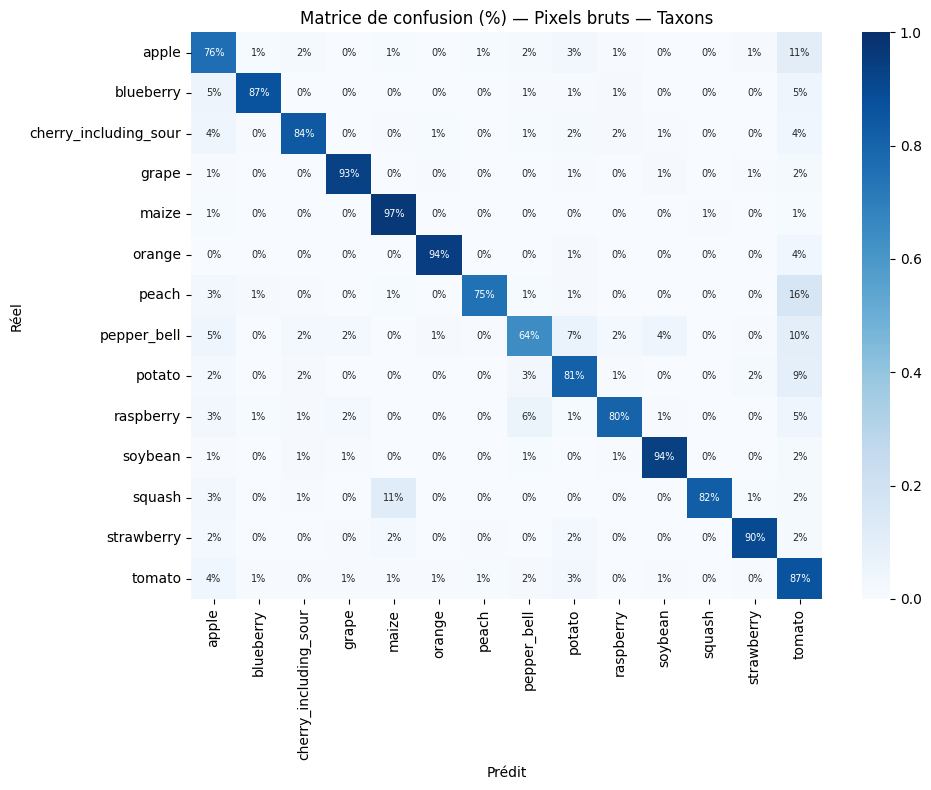

In [ ]:
# ============================================================
# ENTRAÎNEMENT + ÉVALUATION — PIXELS — TAXONS
# ============================================================
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

FEAT_DIR = BASE / "features" / "taxons_raw"
tr = np.load(FEAT_DIR / "train.npz", allow_pickle=True)
te = np.load(FEAT_DIR / "test.npz",  allow_pickle=True)

X_tr_px_taxons, y_tr_str = tr['X'], tr['y']
X_te_px_taxons, y_te_str = te['X'], te['y']

le_px_taxons = LabelEncoder().fit(y_tr_str)
y_tr_px_taxons = le_px_taxons.transform(y_tr_str)
y_te_px_taxons = le_px_taxons.transform(y_te_str)

sw_px_taxons = compute_sample_weight('balanced', y_tr_px_taxons)


# ---------- MESSALINE : Random Forest ----------
# from sklearn.ensemble import RandomForestClassifier
# model_px_taxons = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
# model_px_taxons.fit(X_tr_px_taxons, y_tr_px_taxons)

# ---------- BRONISLAW : Régression logistique ----------
# from sklearn.linear_model import LogisticRegression
# model_px_taxons = LogisticRegression(max_iter=1000, class_weight='balanced')
# model_px_taxons.fit(X_tr_px_taxons, y_tr_px_taxons)

# ---------- PAUL : SVM ----------
# from sklearn.svm import SVC
# model_px_taxons = SVC(class_weight='balanced', random_state=42)
# model_px_taxons.fit(X_tr_px_taxons, y_tr_px_taxons)

# ---------- GHISLAIN : XGBoost ----------
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

model_px_taxons = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                subsample=0.8, colsample_bytree=0.8,
                                tree_method='hist', device='cuda',
                                eval_metric=['mlogloss', 'merror'],
                                callbacks=[EarlyStopping(rounds=20, min_delta=0.001, save_best=True)],
                                random_state=42)
model_px_taxons.fit(X_tr_px_taxons, y_tr_px_taxons, sample_weight=sw_px_taxons,
                    eval_set=[(X_tr_px_taxons, y_tr_px_taxons), (X_te_px_taxons, y_te_px_taxons)],
                    verbose=25)


y_pred = model_px_taxons.predict(X_te_px_taxons)

print("Accuracy :", accuracy_score(y_te_px_taxons, y_pred))
print("F1 macro :", f1_score(y_te_px_taxons, y_pred, average='macro'))
print()
print(classification_report(y_te_px_taxons, y_pred, target_names=le_px_taxons.classes_))

cm = confusion_matrix(y_te_px_taxons, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_pct, cmap='Blues', vmin=0, vmax=1,
            xticklabels=le_px_taxons.classes_, yticklabels=le_px_taxons.classes_,
            annot=True, fmt='.0%', annot_kws={'size':7})
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title("Matrice de confusion (%) — Pixels bruts — Taxons")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
classes = le_px_taxons.classes_
seuil = 20  # n'affiche que les confusions d'au moins 20 images

for i, vraie_classe in enumerate(classes):
    ligne = cm[i]
    total = ligne.sum()
    for j, n in enumerate(ligne):
        if i != j and n >= seuil:
            print(f"{vraie_classe} confondu avec {classes[j]} : {n} images ({n/total*100:.0f}%)")

apple confondu avec cherry_including_sour : 25 images (2%)
apple confondu avec pepper_bell : 26 images (2%)
apple confondu avec potato : 44 images (3%)
apple confondu avec strawberry : 21 images (1%)
apple confondu avec tomato : 154 images (11%)
cherry_including_sour confondu avec apple : 29 images (4%)
cherry_including_sour confondu avec tomato : 25 images (4%)
grape confondu avec tomato : 24 images (2%)
orange confondu avec tomato : 31 images (4%)
peach confondu avec apple : 21 images (3%)
peach confondu avec tomato : 110 images (16%)
pepper_bell confondu avec apple : 34 images (5%)
pepper_bell confondu avec potato : 49 images (7%)
pepper_bell confondu avec soybean : 33 images (4%)
pepper_bell confondu avec tomato : 76 images (10%)
potato confondu avec apple : 22 images (2%)
potato confondu avec pepper_bell : 29 images (3%)
potato confondu avec tomato : 99 images (9%)
raspberry confondu avec pepper_bell : 20 images (6%)
squash confondu avec maize : 38 images (11%)
tomato confondu ave

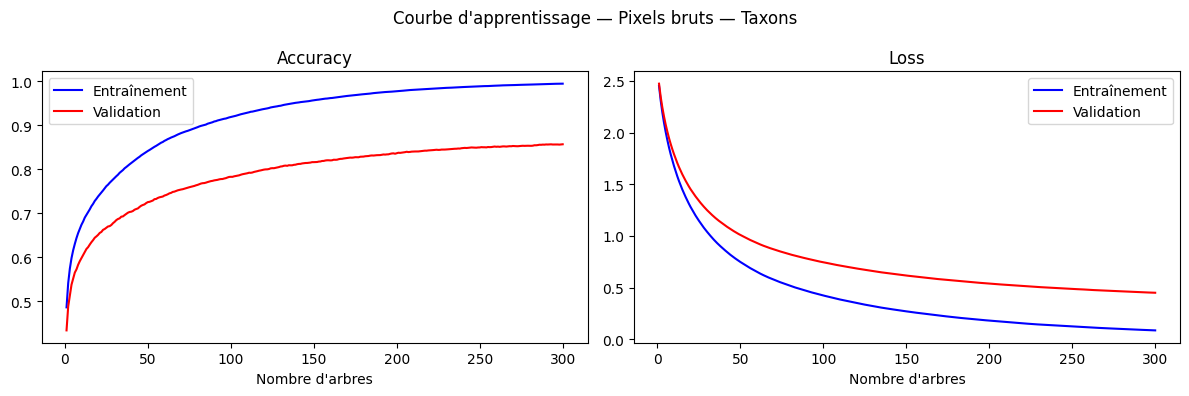

In [ ]:
# ============================================================
# COURBE D'APPRENTISSAGE — PIXELS — TAXONS
# ============================================================
import matplotlib.pyplot as plt

results = model_px_taxons.evals_result()
rounds = range(1, len(results['validation_0']['mlogloss']) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rounds, [1 - e for e in results['validation_0']['merror']], color='blue', label='Entraînement')
plt.plot(rounds, [1 - e for e in results['validation_1']['merror']], color='red', label='Validation')
plt.title('Accuracy')
plt.xlabel("Nombre d'arbres")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rounds, results['validation_0']['mlogloss'], color='blue', label='Entraînement')
plt.plot(rounds, results['validation_1']['mlogloss'], color='red', label='Validation')
plt.title('Loss')
plt.xlabel("Nombre d'arbres")
plt.legend()

plt.suptitle("Courbe d'apprentissage — Pixels bruts — Taxons")
plt.tight_layout()
plt.show()

### **Conclusion — XGBoost Pixels bruts (TAXONS)**

Sur les pixels bruts (32×32, aplatis), XGBoost atteint **85,7 %** d'accuracy et un F1 macro de **0,851** sur le test, pondération des classes (sample_weight) appliquée pour compenser le déséquilibre 12×. **pepper_bell** reste la classe la plus difficile (F1 0,69), suivie d'**apple** (0,77) et **potato** (0,79) ; à l'inverse, **maize** (0,95), **grape** (0,94) et **orange** (0,93) sont les mieux reconnues. La matrice de confusion confirme une diagonale dominante partout, avec une légère tendance de confusion vers **tomato**, la classe la plus fréquente du jeu d'entraînement.
### **Conclusion — Courbe d'apprentissage — Pixels bruts (TAXONS)**

Le train atteint une accuracy quasi parfaite (**0,99**) et une loss proche de 0 (**0,09**) après **300** arbres — comportement attendu pour XGBoost, chaque arbre corrigeant mécaniquement les erreurs du précédent. La validation plafonne nettement plus bas (accuracy **0,86**, loss **0,45**) mais continue de progresser légèrement jusqu'au dernier arbre, sans jamais se stabiliser complètement ni se dégrader : pas de signe de surapprentissage brutal, seulement l'écart structurel habituel entre train et validation pour ce type de modèle sur des pixels bruts sans structure spatiale exploitée.

[0]	validation_0-mlogloss:3.18600	validation_0-merror:0.52914	validation_1-mlogloss:3.26093	validation_1-merror:0.62160
[25]	validation_0-mlogloss:1.07154	validation_0-merror:0.12502	validation_1-mlogloss:1.61395	validation_1-merror:0.34110
[50]	validation_0-mlogloss:0.56592	validation_0-merror:0.05682	validation_1-mlogloss:1.21141	validation_1-merror:0.29229
[75]	validation_0-mlogloss:0.33637	validation_0-merror:0.02516	validation_1-mlogloss:1.01571	validation_1-merror:0.26144
[100]	validation_0-mlogloss:0.21240	validation_0-merror:0.01084	validation_1-mlogloss:0.89476	validation_1-merror:0.23814
[125]	validation_0-mlogloss:0.13887	validation_0-merror:0.00420	validation_1-mlogloss:0.81270	validation_1-merror:0.22366
[150]	validation_0-mlogloss:0.09198	validation_0-merror:0.00172	validation_1-mlogloss:0.75213	validation_1-merror:0.21339
[175]	validation_0-mlogloss:0.06239	validation_0-merror:0.00055	validation_1-mlogloss:0.70515	validation_1-merror:0.20306
[200]	validation_0-mlogloss:0

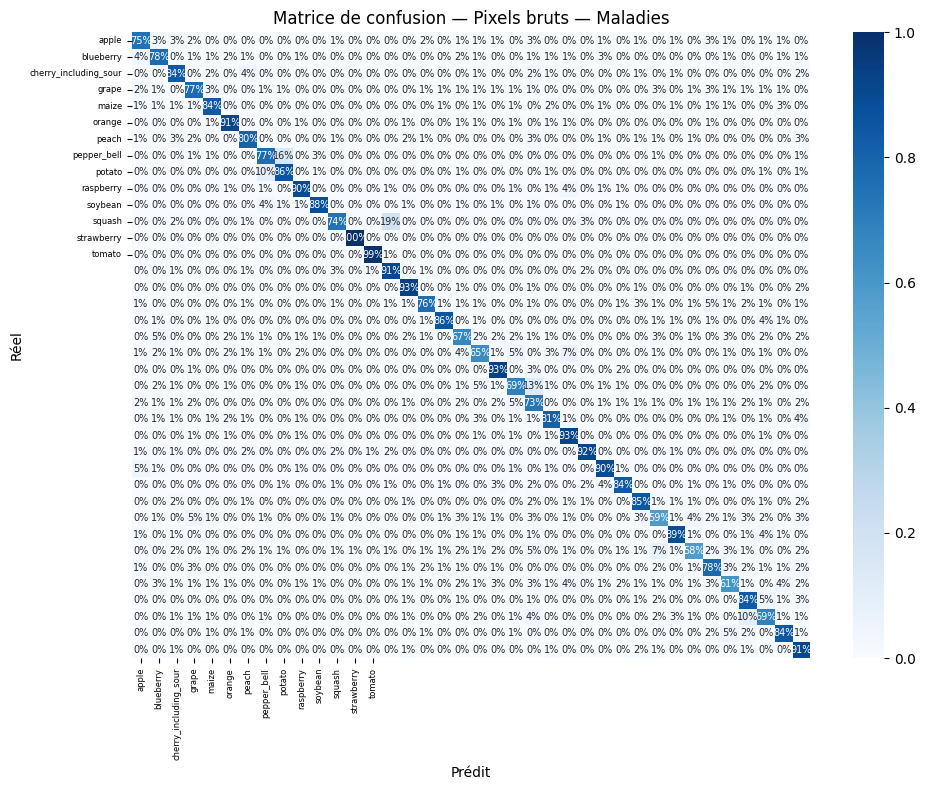

In [ ]:
# ============================================================
# ENTRAÎNEMENT + ÉVALUATION — PIXELS — MALADIES
# ============================================================
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

FEAT_DIR = BASE / "features" / "maladies_raw"
tr = np.load(FEAT_DIR / "train.npz", allow_pickle=True)
te = np.load(FEAT_DIR / "test.npz",  allow_pickle=True)

X_tr_px_maladies, y_tr_str = tr['X'], tr['y']
X_te_px_maladies, y_te_str = te['X'], te['y']

le_px_maladies = LabelEncoder().fit(y_tr_str)
y_tr_px_maladies = le_px_maladies.transform(y_tr_str)
y_te_px_maladies = le_px_maladies.transform(y_te_str)

sw_px_maladies = compute_sample_weight('balanced', y_tr_px_maladies)


# ---------- MESSALINE : Random Forest ----------
# from sklearn.ensemble import RandomForestClassifier
# model_px_maladies = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
# model_px_maladies.fit(X_tr_px_maladies, y_tr_px_maladies)

# ---------- BRONISLAW : Régression logistique ----------
# from sklearn.linear_model import LogisticRegression
# model_px_maladies = LogisticRegression(max_iter=1000, class_weight='balanced')
# model_px_maladies.fit(X_tr_px_maladies, y_tr_px_maladies)

# ---------- PAUL : SVM ----------
# from sklearn.svm import SVC
# model_px_maladies = SVC(class_weight='balanced', random_state=42)
# model_px_maladies.fit(X_tr_px_maladies, y_tr_px_maladies)

# ---------- GHISLAIN : XGBoost ----------
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

model_px_maladies = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                  subsample=0.8, colsample_bytree=0.8,
                                  tree_method='hist', device='cuda',
                                  eval_metric=['mlogloss', 'merror'],
                                  callbacks=[EarlyStopping(rounds=20, min_delta=0.001, save_best=True)],
                                  random_state=42)
model_px_maladies.fit(X_tr_px_maladies, y_tr_px_maladies, sample_weight=sw_px_maladies,
                      eval_set=[(X_tr_px_maladies, y_tr_px_maladies), (X_te_px_maladies, y_te_px_maladies)],
                      verbose=25)


y_pred = model_px_maladies.predict(X_te_px_maladies)

print("Accuracy :", accuracy_score(y_te_px_maladies, y_pred))
print("F1 macro :", f1_score(y_te_px_maladies, y_pred, average='macro'))
print()
print(classification_report(y_te_px_maladies, y_pred, target_names=le_px_maladies.classes_))

cm = confusion_matrix(y_te_px_maladies, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_pct, cmap='Blues', vmin=0, vmax=1,
            xticklabels=le_px_taxons.classes_, yticklabels=le_px_taxons.classes_,
            annot=True, fmt='.0%', annot_kws={'size':7})
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title("Matrice de confusion (%) — Pixels bruts — Maladies")
plt.title("Matrice de confusion — Pixels bruts — Maladies")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

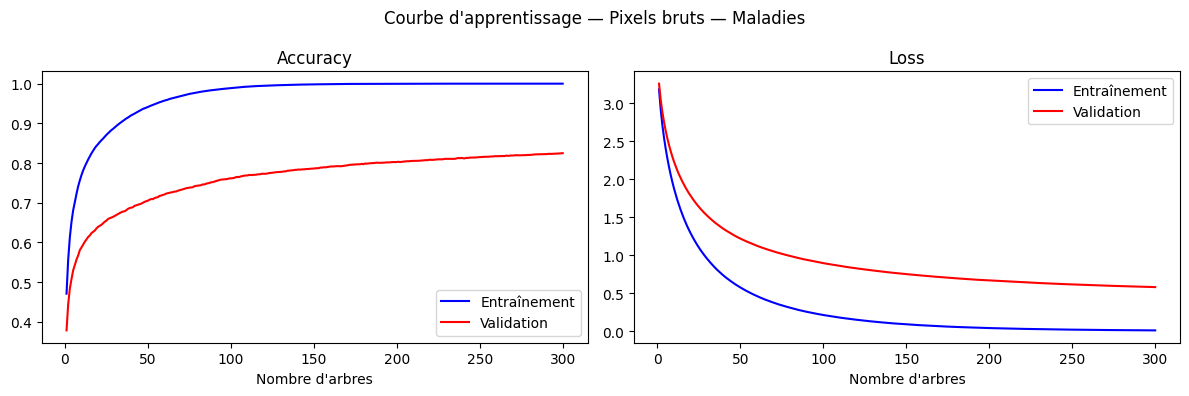

In [ ]:
# ============================================================
# COURBE D'APPRENTISSAGE — PIXELS — MALADIES
# ============================================================
import matplotlib.pyplot as plt

results = model_px_maladies.evals_result()
rounds = range(1, len(results['validation_0']['mlogloss']) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rounds, [1 - e for e in results['validation_0']['merror']], color='blue', label='Entraînement')
plt.plot(rounds, [1 - e for e in results['validation_1']['merror']], color='red', label='Validation')
plt.title('Accuracy')
plt.xlabel("Nombre d'arbres")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rounds, results['validation_0']['mlogloss'], color='blue', label='Entraînement')
plt.plot(rounds, results['validation_1']['mlogloss'], color='red', label='Validation')
plt.title('Loss')
plt.xlabel("Nombre d'arbres")
plt.legend()

plt.suptitle("Courbe d'apprentissage — Pixels bruts — Maladies")
plt.tight_layout()
plt.show()

### **Conclusion — XGBoost Pixels bruts (MALADIES)**

Sur les pixels bruts (32×32, aplatis), XGBoost atteint **82,4 %** d'accuracy et un F1 macro de **0,814** sur les 38 classes, pondération appliquée pour compenser le déséquilibre. Les classes les mieux reconnues sont concentrées chez **maize** (common_rust et healthy à 0,99) et **orange___haunglongbing_citrus_greening** (0,94, la classe la plus fournie du test). À l'inverse, la faiblesse se concentre nettement sur les maladies de **tomato** — early_blight et septoria_leaf_spot (F1 ≈ 0,63), late_blight (0,67), target_spot (0,69) — ainsi que **potato___late_blight** (précision 0,58). Cette concentration des erreurs au sein d'une même espèce, plutôt qu'un éparpillement aléatoire, est cohérente avec une réelle similarité visuelle entre plusieurs maladies foliaires (taches, brûlures) que 32×32 pixels bruts peinent à distinguer. La matrice de confusion confirme une diagonale dominante partout, sans paire de confusion isolée qui domine le reste.
### **Conclusion — Courbe d'apprentissage — Pixels bruts (MALADIES)**

Le train atteint un ajustement parfait (merror = 0, mlogloss ≈ 0,014) dès l'arbre environ **225 **— mémorisation complète des 67 000+ images d'entraînement, sur les 38 classes. La validation continue de progresser légèrement jusqu'au dernier arbre sans jamais se dégrader, mais plafonne à **82,5** % d'accuracy et 0,58 de loss : un écart train/validation d'environ 17,5 points, plus marqué que celui observé sur TAXONS (~13 points). Cohérent avec la granularité plus fine de la tâche (38 classes contre 14) : plus de place pour que le modèle capture des détails propres au train qui ne se généralisent pas à l'identique. Même lecture que pour TAXONS — écart de généralisation, pas de dégradation active de la validation — probablement la limite intrinsèque des pixels bruts face à un nombre de classes élevé et visuellement proches, plus qu'un problème de réglage.

[0]	validation_0-mlogloss:2.45963	validation_0-merror:0.51550	validation_1-mlogloss:2.48038	validation_1-merror:0.57088
[25]	validation_0-mlogloss:1.15206	validation_0-merror:0.20891	validation_1-mlogloss:1.37099	validation_1-merror:0.32778
[50]	validation_0-mlogloss:0.75462	validation_0-merror:0.13447	validation_1-mlogloss:1.04211	validation_1-merror:0.26772
[75]	validation_0-mlogloss:0.54273	validation_0-merror:0.09037	validation_1-mlogloss:0.86897	validation_1-merror:0.23263
[100]	validation_0-mlogloss:0.40722	validation_0-merror:0.06116	validation_1-mlogloss:0.75668	validation_1-merror:0.20932
[125]	validation_0-mlogloss:0.31414	validation_0-merror:0.04276	validation_1-mlogloss:0.67847	validation_1-merror:0.19281
[150]	validation_0-mlogloss:0.24504	validation_0-merror:0.02959	validation_1-mlogloss:0.61937	validation_1-merror:0.17894
[175]	validation_0-mlogloss:0.19486	validation_0-merror:0.02065	validation_1-mlogloss:0.57483	validation_1-merror:0.16792
[200]	validation_0-mlogloss:0

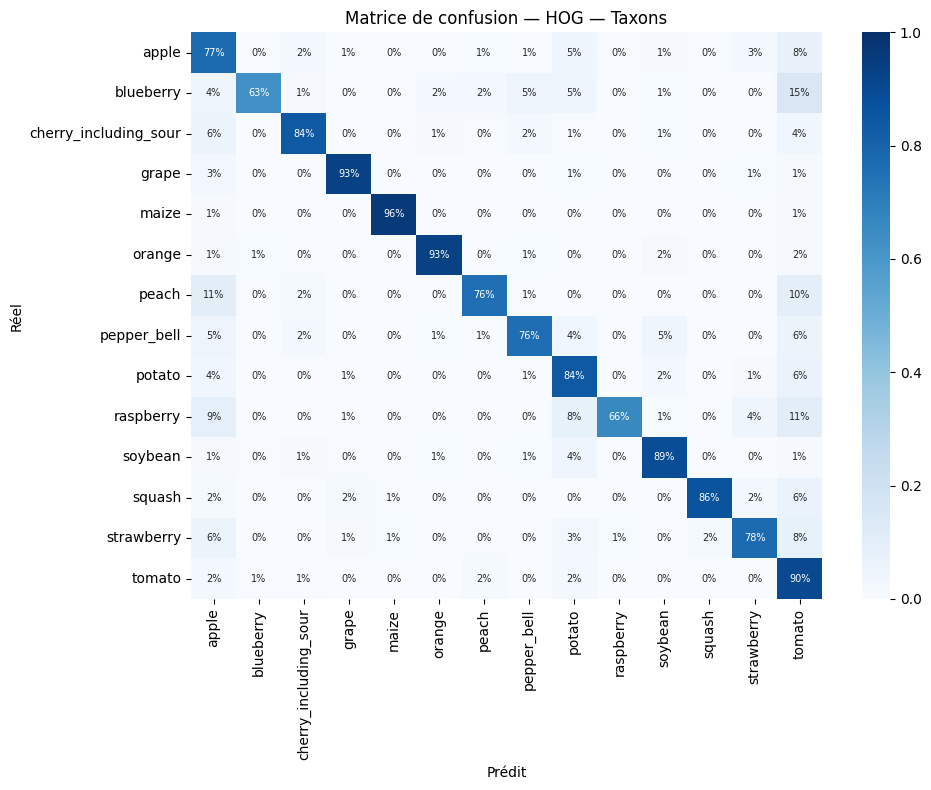

In [ ]:
# ============================================================
# ENTRAÎNEMENT + ÉVALUATION — HOG — TAXONS
# ============================================================
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

FEAT_DIR = BASE / "features" / "taxons_hog"
tr = np.load(FEAT_DIR / "train.npz", allow_pickle=True)
te = np.load(FEAT_DIR / "test.npz",  allow_pickle=True)

X_tr_hog_taxons, y_tr_str = tr['X'], tr['y']
X_te_hog_taxons, y_te_str = te['X'], te['y']

le_hog_taxons = LabelEncoder().fit(y_tr_str)
y_tr_hog_taxons = le_hog_taxons.transform(y_tr_str)
y_te_hog_taxons = le_hog_taxons.transform(y_te_str)

sw_hog_taxons = compute_sample_weight('balanced', y_tr_hog_taxons)


# ---------- MESSALINE : Random Forest ----------
# from sklearn.ensemble import RandomForestClassifier
# model_hog_taxons = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
# model_hog_taxons.fit(X_tr_hog_taxons, y_tr_hog_taxons)

# ---------- BRONISLAW : Régression logistique ----------
# from sklearn.linear_model import LogisticRegression
# model_hog_taxons = LogisticRegression(max_iter=1000, class_weight='balanced')
# model_hog_taxons.fit(X_tr_hog_taxons, y_tr_hog_taxons)

# ---------- PAUL : SVM ----------
# from sklearn.svm import SVC
# model_hog_taxons = SVC(class_weight='balanced', random_state=42)
# model_hog_taxons.fit(X_tr_hog_taxons, y_tr_hog_taxons)

# ---------- GHISLAIN : XGBoost ----------
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

model_hog_taxons = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                 subsample=0.8, colsample_bytree=0.8,
                                 tree_method='hist', device='cuda',
                                 eval_metric=['mlogloss', 'merror'],
                                 callbacks=[EarlyStopping(rounds=20, min_delta=0.001, save_best=True)],
                                 random_state=42)
model_hog_taxons.fit(X_tr_hog_taxons, y_tr_hog_taxons, sample_weight=sw_hog_taxons,
                     eval_set=[(X_tr_hog_taxons, y_tr_hog_taxons), (X_te_hog_taxons, y_te_hog_taxons)],
                     verbose=25)


y_pred = model_hog_taxons.predict(X_te_hog_taxons)

print("Accuracy :", accuracy_score(y_te_hog_taxons, y_pred))
print("F1 macro :", f1_score(y_te_hog_taxons, y_pred, average='macro'))
print()
print(classification_report(y_te_hog_taxons, y_pred, target_names=le_hog_taxons.classes_))

cm = confusion_matrix(y_te_hog_taxons, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_pct, cmap='Blues', vmin=0, vmax=1,
            xticklabels=le_px_taxons.classes_, yticklabels=le_px_taxons.classes_,
            annot=True, fmt='.0%', annot_kws={'size':7})
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title("Matrice de confusion — HOG — Taxons")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

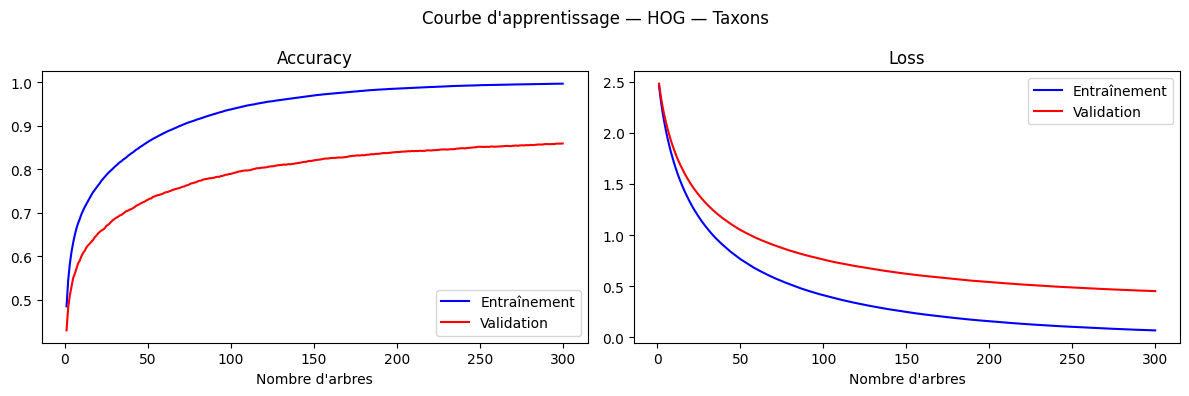

In [ ]:
# ============================================================
# COURBE D'APPRENTISSAGE — HOG — TAXONS
# ============================================================
import matplotlib.pyplot as plt

results = model_hog_taxons.evals_result()
rounds = range(1, len(results['validation_0']['mlogloss']) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rounds, [1 - e for e in results['validation_0']['merror']], color='blue', label='Entraînement')
plt.plot(rounds, [1 - e for e in results['validation_1']['merror']], color='red', label='Validation')
plt.title('Accuracy')
plt.xlabel("Nombre d'arbres")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rounds, results['validation_0']['mlogloss'], color='blue', label='Entraînement')
plt.plot(rounds, results['validation_1']['mlogloss'], color='red', label='Validation')
plt.title('Loss')
plt.xlabel("Nombre d'arbres")
plt.legend()

plt.suptitle("Courbe d'apprentissage — HOG — Taxons")
plt.tight_layout()
plt.show()

### **Conclusion — XGBoost HOG (TAXONS)**

Sur les features HOG, XGBoost atteint 85,9 % d'accuracy et un F1 macro de 0,839 — accuracy quasi identique aux pixels bruts (85,7 %), mais F1 macro légèrement en retrait (0,839 contre 0,851). HOG n'est donc pas strictement meilleur : il redistribue la performance différemment selon les classes plutôt que d'améliorer uniformément.

**pepper_bell** progresse nettement (F1 0,69 → 0,81) — cohérent avec HOG, qui capte la forme des feuilles plutôt que leur couleur. À l'inverse, **blueberry** (0,86 → 0,71) et **raspberry** (0,81 → 0,76) reculent sensiblement : ces baies se distinguent probablement davantage par la couleur que par la forme, un signal que HOG jette précisément en travaillant sur l'image en niveaux de gris. La matrice de confusion confirme une diagonale dominante partout, sans confusion isolée qui domine le reste.

### **Conclusion — Courbe d'apprentissage — HOG (TAXONS)**

Le train atteint une accuracy quasi parfaite (99,7 %) et une loss proche de 0 (0,068) après 300 arbres. La validation plafonne à 85,9 % d'accuracy et 0,45 de loss, en légère progression continue jusqu'au dernier arbre, sans dégradation. L'écart train/validation (13,8 points) est quasiment identique à celui observé sur les pixels bruts (13,8 points également) — malgré ses 1 764 dimensions contre 64, HOG ne réduit ni n'aggrave ce schéma structurel : même comportement d'écart de généralisation, sans signe de dégradation active de la validation.

[0]	validation_0-mlogloss:3.24171	validation_0-merror:0.56321	validation_1-mlogloss:3.32165	validation_1-merror:0.66923
[25]	validation_0-mlogloss:1.22750	validation_0-merror:0.14610	validation_1-mlogloss:1.83998	validation_1-merror:0.40488
[50]	validation_0-mlogloss:0.68720	validation_0-merror:0.06353	validation_1-mlogloss:1.45373	validation_1-merror:0.36002
[75]	validation_0-mlogloss:0.42336	validation_0-merror:0.02836	validation_1-mlogloss:1.25571	validation_1-merror:0.33001
[100]	validation_0-mlogloss:0.27409	validation_0-merror:0.01166	validation_1-mlogloss:1.13494	validation_1-merror:0.30990
[125]	validation_0-mlogloss:0.18288	validation_0-merror:0.00454	validation_1-mlogloss:1.05209	validation_1-merror:0.29506
[150]	validation_0-mlogloss:0.12376	validation_0-merror:0.00175	validation_1-mlogloss:0.98897	validation_1-merror:0.28342
[175]	validation_0-mlogloss:0.08533	validation_0-merror:0.00053	validation_1-mlogloss:0.94113	validation_1-merror:0.27468
[200]	validation_0-mlogloss:0

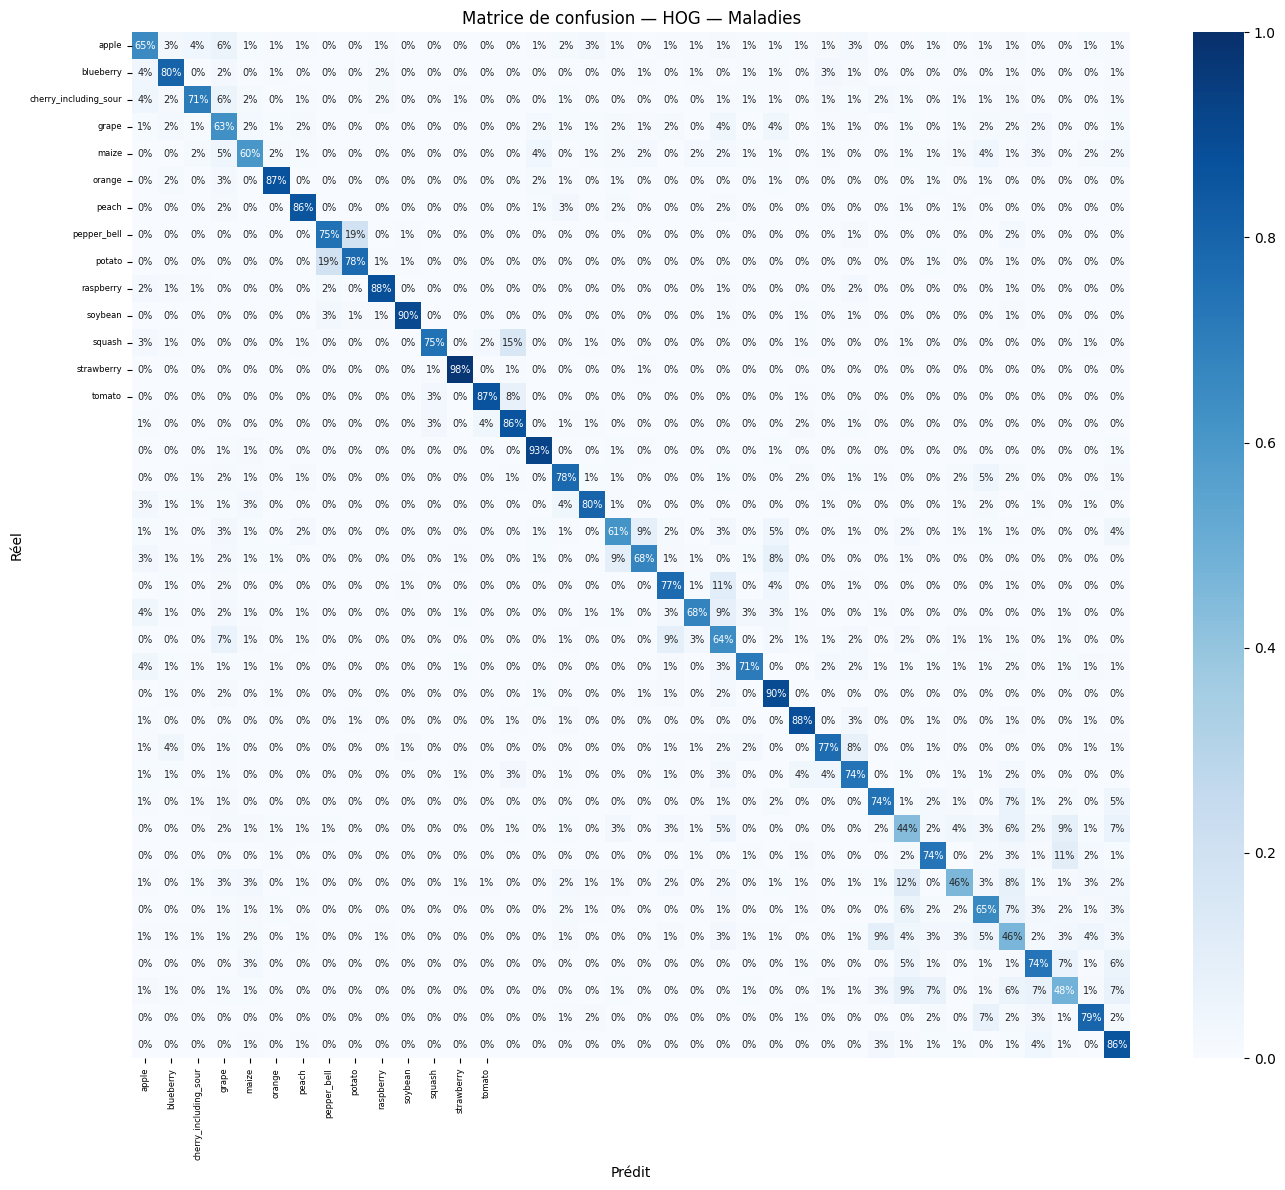

In [ ]:
# ============================================================
# ENTRAÎNEMENT + ÉVALUATION — HOG — MALADIES
# ============================================================
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

FEAT_DIR = BASE / "features" / "maladies_hog"
tr = np.load(FEAT_DIR / "train.npz", allow_pickle=True)
te = np.load(FEAT_DIR / "test.npz",  allow_pickle=True)

X_tr_hog_maladies, y_tr_str = tr['X'], tr['y']
X_te_hog_maladies, y_te_str = te['X'], te['y']

le_hog_maladies = LabelEncoder().fit(y_tr_str)
y_tr_hog_maladies = le_hog_maladies.transform(y_tr_str)
y_te_hog_maladies = le_hog_maladies.transform(y_te_str)

sw_hog_maladies = compute_sample_weight('balanced', y_tr_hog_maladies)


# ---------- MESSALINE : Random Forest ----------
# from sklearn.ensemble import RandomForestClassifier
# model_hog_maladies = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
# model_hog_maladies.fit(X_tr_hog_maladies, y_tr_hog_maladies)

# ---------- BRONISLAW : Régression logistique ----------
# from sklearn.linear_model import LogisticRegression
# model_hog_maladies = LogisticRegression(max_iter=1000, class_weight='balanced')
# model_hog_maladies.fit(X_tr_hog_maladies, y_tr_hog_maladies)

# ---------- PAUL : SVM ----------
# from sklearn.svm import SVC
# model_hog_maladies = SVC(class_weight='balanced', random_state=42)
# model_hog_maladies.fit(X_tr_hog_maladies, y_tr_hog_maladies)

# ---------- GHISLAIN : XGBoost ----------
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

model_hog_maladies = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                   subsample=0.8, colsample_bytree=0.8,
                                   tree_method='hist', device='cuda',
                                   eval_metric=['mlogloss', 'merror'],
                                   callbacks=[EarlyStopping(rounds=20, min_delta=0.001, save_best=True)],
                                   random_state=42)
model_hog_maladies.fit(X_tr_hog_maladies, y_tr_hog_maladies, sample_weight=sw_hog_maladies,
                       eval_set=[(X_tr_hog_maladies, y_tr_hog_maladies), (X_te_hog_maladies, y_te_hog_maladies)],
                       verbose=25)


y_pred = model_hog_maladies.predict(X_te_hog_maladies)

print("Accuracy :", accuracy_score(y_te_hog_maladies, y_pred))
print("F1 macro :", f1_score(y_te_hog_maladies, y_pred, average='macro'))
print()
print(classification_report(y_te_hog_maladies, y_pred, target_names=le_hog_maladies.classes_))

cm = confusion_matrix(y_te_hog_maladies, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_pct, cmap='Blues', vmin=0, vmax=1,
            xticklabels=le_px_taxons.classes_, yticklabels=le_px_taxons.classes_,
            annot=True, fmt='.0%', annot_kws={'size':7})
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title("Matrice de confusion — HOG — Maladies")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

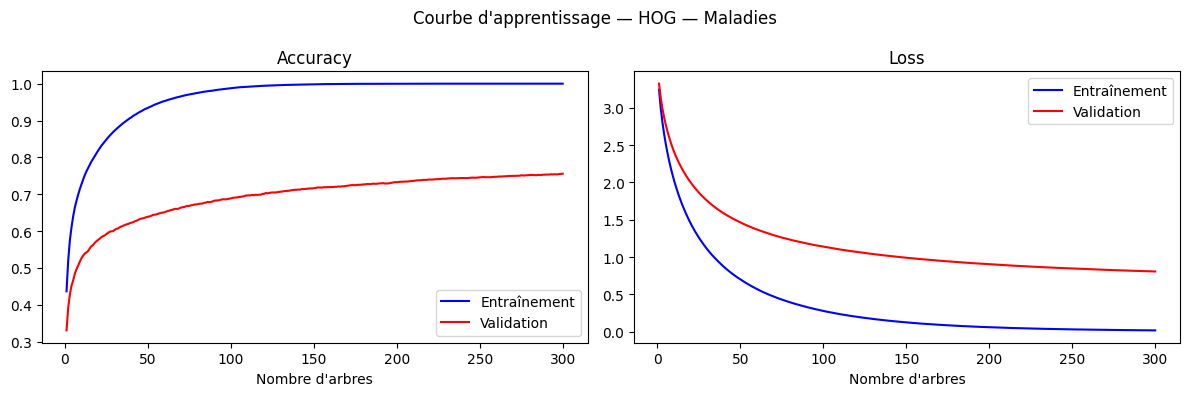

In [ ]:
# ============================================================
# COURBE D'APPRENTISSAGE — HOG — MALADIES
# ============================================================
import matplotlib.pyplot as plt

results = model_hog_maladies.evals_result()
rounds = range(1, len(results['validation_0']['mlogloss']) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rounds, [1 - e for e in results['validation_0']['merror']], color='blue', label='Entraînement')
plt.plot(rounds, [1 - e for e in results['validation_1']['merror']], color='red', label='Validation')
plt.title('Accuracy')
plt.xlabel("Nombre d'arbres")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rounds, results['validation_0']['mlogloss'], color='blue', label='Entraînement')
plt.plot(rounds, results['validation_1']['mlogloss'], color='red', label='Validation')
plt.title('Loss')
plt.xlabel("Nombre d'arbres")
plt.legend()

plt.suptitle("Courbe d'apprentissage — HOG — Maladies")
plt.tight_layout()
plt.show()

### **Conclusion — XGBoost HOG (MALADIES)**

Sur les features HOG, XGBoost atteint 75,5 % d'accuracy et un F1 macro de 0,743 — nettement en retrait par rapport aux pixels bruts sur cette même base (82,4 % / 0,814, soit -6,9 et -7,1 points). C'est un recul bien plus marqué que celui observé sur TAXONS (F1 macro -1,2 point seulement), un signal clair que HOG pénalise MALADIES spécifiquement.

L'explication la plus probable tient à la nature même de la tâche : contrairement à TAXONS, où il faut distinguer des espèces aux formes de feuilles différentes, MALADIES doit repérer des symptômes qui se manifestent presque toujours par un changement de **couleur ou de texture de surface** (jaunissement, taches, brunissement) sur une feuille dont la forme reste identique entre l'état sain et malade. HOG travaille en niveaux de gris et jette précisément ce signal. Le sous-groupe tomato, déjà le plus faible sous pixels bruts, s'effondre encore davantage : septoria_leaf_spot (0,63 → 0,42), target_spot (0,69 → 0,51), late_blight (0,67 → 0,54), leaf_mold (0,77 → 0,62). À l'inverse, les classes déjà fortes et morphologiquement bien identifiables restent solides (maize, orange___haunglongbing_citrus_greening, soybean___healthy).

Élément à retenir pour la comparaison Pixels/HOG demandée par le jury : le choix de features n'a pas le même impact selon la base — HOG est globalement neutre à légèrement défavorable sur TAXONS, mais clairement défavorable sur MALADIES.

### **Conclusion — Courbe d'apprentissage — HOG (MALADIES)**

Le train atteint un ajustement parfait (accuracy ≈ 100 %, loss ≈ 0,02) dès l'arbre ~100. La validation plafonne à 75,6 % d'accuracy et 0,81 de loss, en légère progression continue jusqu'au dernier arbre, sans dégradation — l'écart train/validation atteint 24,4 points, le plus large des quatre combinaisons testées (contre 13,8 points pour Pixels et HOG sur TAXONS, et 17,5 points pour Pixels sur MALADIES). Ce n'est pas un excès de mémorisation différent des trois autres runs — le train touche déjà 100 % partout, XGBoost a systématiquement la capacité de tout apprendre par cœur quel que soit le jeu de features. L'écart plus large ici vient du plafond de validation plus bas (75,6 % contre 82,5-85,9 % ailleurs), cohérent avec la lecture déjà posée sur la matrice de confusion : HOG retire précisément le signal couleur dont MALADIES a le plus besoin, ce qui limite ce que le modèle peut extraire, sans que ça change sa capacité à mémoriser le train.

### **Conclusion — Pixels bruts vs HOG (TAXONS et MALADIES)**

| | Accuracy | F1 macro | Écart train/val |
|---|---|---|---|
| Pixels — TAXONS | 85,7 % | 0,851 | 13,8 pts |
| HOG — TAXONS | 85,9 % | 0,839 | 13,8 pts |
| Pixels — MALADIES | 82,4 % | 0,814 | 17,5 pts |
| HOG — MALADIES | 75,5 % | 0,743 | 24,4 pts |

Les pixels bruts l'emportent sur les deux bases en F1 macro — de justesse sur TAXONS (-1,2 point pour HOG), nettement sur MALADIES (-7,1 points, et l'écart train/validation le plus large des quatre combinaisons). HOG encode la forme des contours à partir d'une image en niveaux de gris : il jette la couleur, information secondaire pour distinguer des espèces aux silhouettes différentes (TAXONS), mais souvent le signal principal des symptômes de maladie (jaunissement, taches, brunissement) sur une feuille dont la forme ne change pas (MALADIES). Ce projet confirme que la couleur porte plus d'information utile que la forme pour détecter des maladies.